In [ ]:
import pandas as pd
from scipy.signal import medfilt
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
SAMPLING_RATE = 240  # Hz
SKIP_TRIALS = {"Trial43.csv"}  # Different schema (34 channels, V/s units)
SENSOR_COLUMNS = ["25", "26", "27", "28", "29", "30", "31", "32"]

In [ ]:
def load_raw_trial(filepath: str) -> pd.DataFrame:
    """
    Load a raw pitch trial CSV file.

    The raw files have TWO sections concatenated:
    Section 1 (voltage data - what we want):
    - Row 0: Device type ("Devices")
    - Row 1: Sampling rate (240)
    - Row 2: Metadata
    - Row 3: Column headers (Frame, Sub Frame, 25-32)
    - Row 4: Units (V)
    - Row 5+: Data

    Section 2 (derivative data - ignore):
    - Starts with another "Devices" line mid-file
    - Has 34 columns with V/s units

    We only read Section 1.
    """
    # First, read the file line by line to find where Section 2 starts
    with open(filepath, "r", encoding="utf-8-sig") as f:
        lines = f.readlines()

    # Find the second occurrence of "Devices" (start of Section 2)
    devices_indices = []
    for i, line in enumerate(lines):
        if line.strip().startswith("Devices"):
            devices_indices.append(i)

    # Determine how many lines to read (stop before Section 2)
    if len(devices_indices) >= 2:
        nrows = devices_indices[1] - 5  # Subtract header rows (0-4)
    else:
        nrows = None  # Read all if only one section

    # Read with header at row 3 (0-indexed), skip rows 0-2 and row 4 (units)
    df = pd.read_csv(filepath, header=3, skiprows=[4], nrows=nrows, encoding="utf-8-sig")

    # Clean column names (remove any whitespace)
    df.columns = df.columns.str.strip()

    df['time_step'] = np.arange(len(df)) / SAMPLING_RATE
    # Keep only Frame, Sub Frame, and sensor columns
    keep_cols = ["time_step"] + SENSOR_COLUMNS
    available_cols = [c for c in keep_cols if c in df.columns]
    df = df[available_cols].copy()

    # Drop rows with NaN values (from empty lines in raw data)
    df = df.dropna()

    return df

In [ ]:
def convert_volt_to_ohms(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert voltage readings to resistance (ohms) using the formula:
    R = (V * 1000) / (1-V/5)
    """
    for col in SENSOR_COLUMNS:
        if col in df.columns:
            df[col] = (df[col] * 1000) / (1 - df[col]/5)
    return df

In [ ]:
df = load_raw_trial("pitch/good/unprocessed_data/Trial44.csv")
df

In [ ]:
convert_volt_to_ohms(df)

In [ ]:
signal = df['26'].to_numpy()
plt.plot(df['time_step'], ts)

In [36]:

"""
fft_viz.py  —  muscle contraction signal edition
─────────────────────────────────────────────────
Designed for short (~1-10 s) single-point expansion/contraction signals
(MMG, accelerometer, force sensor) sampled at low-to-mid rates.

Usage:
    from fft_viz import plot_fft

    plot_fft(signal, sr=240)
    plot_fft(signal, sr=240, bandpass=(2, 40), nperseg=64, save="pitch.png")

Key differences from generic FFT viz:
  - Bandpass filter removes slow contraction trend (default 2–80 Hz)
    so FFT shows actual muscle oscillation, not just the movement envelope
  - nperseg auto-scaled to signal length (avoids half-signal windows)
  - Raw + filtered signals overlaid in time plot
  - Median frequency line shown on spectrogram (tracks fatigue/effort)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import stft, butter, sosfiltfilt


def _bandpass(signal, sr, low, high):
    """Zero-phase Butterworth bandpass filter."""
    nyq = sr / 2
    low_c  = max(low,  0.01) / nyq
    high_c = min(high / nyq, 0.99)
    sos = butter(4, [low_c, high_c], btype="band", output="sos")
    return sosfiltfilt(sos, signal)


def plot_fft(
    signal: np.ndarray,
    sr: float = 240,
    bandpass: tuple = (2, 80),
    max_freq: float = None,
    nperseg: int = None,
    noverlap: int = None,
    save: str = None,
    title: str = "Muscle contraction — FFT & STFT",
):
    """
    Parameters
    ----------
    signal    : 1-D numpy array (raw sensor values)
    sr        : sample rate in Hz
    bandpass  : (low_hz, high_hz) removes slow trend + high noise.
                Set to None to skip filtering.
    max_freq  : upper freq limit on plots; default = min(sr/2, bandpass[1]*1.5)
    nperseg   : STFT window samples; default = sr//4 (250 ms windows)
    noverlap  : STFT overlap; default = 87.5% of nperseg
    save      : file path to save PNG; None = interactive window
    title     : figure title
    """
    signal = np.asarray(signal, dtype=float).squeeze()
    assert signal.ndim == 1, "signal must be 1-D"

    N        = len(signal)
    t        = np.linspace(0, N / sr, N, endpoint=False)
    duration = N / sr

    # ── Filter ───────────────────────────────────────────────────────────────
    if bandpass is not None:
        low, high = bandpass
        high = min(high, sr / 2 * 0.95)
        low  = min(low, high * 0.9)
        filtered = _bandpass(signal, sr, low, high)
    else:
        filtered = signal - signal.mean()   # at least remove DC

    # ── Window sizing — keep nperseg ≤ N/4 for meaningful STFT ───────────────
    if nperseg is None:
        nperseg = min(int(sr // 4), N // 4)
        nperseg = max(nperseg, 16)
        # round down to nearest power of 2 for FFT efficiency
        nperseg = int(2 ** np.floor(np.log2(nperseg)))
    if noverlap is None:
        noverlap = int(nperseg * 0.875)
    if max_freq is None:
        max_freq = min(sr / 2, (bandpass[1] * 1.5) if bandpass else sr / 2)

    # ── FFT (on filtered signal) ──────────────────────────────────────────────
    fft_vals = np.fft.rfft(filtered)
    fft_mag  = np.abs(fft_vals) / N * 2
    freqs    = np.fft.rfftfreq(N, d=1.0 / sr)

    # Mean frequency (power-weighted centre of mass)
    mask       = (freqs >= (bandpass[0] if bandpass else 0)) & (freqs <= max_freq)
    power      = fft_mag[mask] ** 2
    mean_freq  = np.sum(freqs[mask] * power) / np.sum(power) if power.sum() > 0 else 0

    # ── STFT ─────────────────────────────────────────────────────────────────
    f_stft, t_stft, Zxx = stft(filtered, fs=sr, nperseg=nperseg,
                                noverlap=noverlap, window="hann")
    mag_db = 20 * np.log10(np.abs(Zxx) + 1e-10)
    db_min = mag_db.max() - 50

    # Instantaneous median frequency per time frame
    freq_mask = f_stft <= max_freq
    power_t   = np.abs(Zxx[freq_mask, :]) ** 2
    cum_power = np.cumsum(power_t, axis=0)
    half      = cum_power[-1, :] / 2
    med_freq  = np.array([
        f_stft[freq_mask][np.searchsorted(cum_power[:, i], half[i])]
        for i in range(cum_power.shape[1])
    ])

    # ── Style ─────────────────────────────────────────────────────────────────
    BLUE     = "#3B8BD4"
    ORANGE   = "#E8593C"
    GREEN    = "#4CAF82"
    BG       = "#0d0d0d"
    PANEL_BG = "#141414"
    TEXT     = "#d4d2cc"
    GRID     = "#2a2a2a"

    plt.rcParams.update({
        "figure.facecolor": BG,   "text.color":      TEXT,
        "axes.facecolor":   PANEL_BG, "axes.edgecolor":  "#333",
        "axes.labelcolor":  TEXT,  "xtick.color":     TEXT,
        "ytick.color":      TEXT,  "grid.color":      GRID,
        "font.family":      "sans-serif", "font.size": 10,
    })

    fig = plt.figure(figsize=(14, 10), facecolor=BG)
    fig.suptitle(title, fontsize=15, color=TEXT, fontweight="medium", y=0.97)

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           hspace=0.45, wspace=0.35,
                           left=0.07, right=0.97, top=0.92, bottom=0.07)

    # ── 1. Time domain: raw + filtered overlay ────────────────────────────────
    ax_time = fig.add_subplot(gs[0, :])
    ax_time.plot(t, signal,   color=BLUE,   linewidth=0.6, alpha=0.4, label="raw")
    ax_time.plot(t, filtered + signal.mean(), color=ORANGE, linewidth=0.9,
                 alpha=0.85, label=f"filtered {bandpass[0]}–{bandpass[1]} Hz")
    ax_time.set_title("Time-domain signal", loc="left", pad=6, fontsize=11)
    ax_time.set_xlabel("Time (s)")
    ax_time.set_ylabel("Amplitude")
    ax_time.grid(True, linewidth=0.4)
    ax_time.set_xlim(0, duration)
    ax_time.legend(loc="upper left", fontsize=8,
                   facecolor=PANEL_BG, edgecolor="#333", labelcolor=TEXT)

    stats = (f"n={N:,}  sr={sr:.0f} Hz  duration={duration:.2f}s  "
             f"min={signal.min():.1f}  max={signal.max():.1f}  "
             f"mean freq={mean_freq:.1f} Hz")
    ax_time.text(0.99, 0.04, stats, transform=ax_time.transAxes,
                 ha="right", va="bottom", fontsize=8, color="#888", style="italic")

    # ── 2. FFT spectrum ───────────────────────────────────────────────────────
    ax_fft = fig.add_subplot(gs[1, 0])
    vis = freqs <= max_freq
    ax_fft.fill_between(freqs[vis], fft_mag[vis], color=BLUE, alpha=0.3)
    ax_fft.plot(freqs[vis], fft_mag[vis], color=BLUE, linewidth=1.2)
    ax_fft.axvline(mean_freq, color=GREEN, linewidth=1.2, linestyle="--", alpha=0.8)
    ax_fft.text(mean_freq + max_freq * 0.02, ax_fft.get_ylim()[1] * 0.02,
                f"mean {mean_freq:.1f} Hz", color=GREEN, fontsize=8)

    # Top-3 peak annotations
    vis_mag   = fft_mag[vis]
    vis_freqs = freqs[vis]
    top3 = np.argsort(vis_mag)[-3:][::-1]
    for idx in top3:
        if vis_mag[idx] > vis_mag.max() * 0.1:
            ax_fft.annotate(f"{vis_freqs[idx]:.1f} Hz",
                            xy=(vis_freqs[idx], vis_mag[idx]),
                            xytext=(vis_freqs[idx] + max_freq * 0.05, vis_mag[idx] * 0.92),
                            color=TEXT, fontsize=8,
                            arrowprops=dict(arrowstyle="->", color=TEXT, lw=0.7))

    ax_fft.set_title("FFT spectrum  (filtered, no time info)", loc="left", pad=6, fontsize=11)
    ax_fft.set_xlabel("Frequency (Hz)")
    ax_fft.set_ylabel("Amplitude")
    ax_fft.set_xlim(0, max_freq)
    ax_fft.grid(True, linewidth=0.4)
    note = (f"window={nperseg}  overlap={noverlap}\n"
            f"Δf={sr/N:.2f} Hz  Δt={(nperseg-noverlap)/sr*1000:.0f} ms/frame")
    ax_fft.text(0.97, 0.95, note, transform=ax_fft.transAxes,
                ha="right", va="top", fontsize=8, color="#888", style="italic")

    # ── 3. STFT spectrogram + median freq line ────────────────────────────────
    ax_spec = fig.add_subplot(gs[1, 1])
    im = ax_spec.pcolormesh(t_stft, f_stft[freq_mask], mag_db[freq_mask],
                             cmap="inferno", shading="gouraud",
                             vmin=db_min, vmax=mag_db.max())
    ax_spec.plot(t_stft, med_freq, color=GREEN, linewidth=1.2,
                 linestyle="--", alpha=0.85, label="median freq")
    ax_spec.set_ylim(0, max_freq)
    ax_spec.set_title("STFT spectrogram  (time + frequency)", loc="left", pad=6, fontsize=11)
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.legend(loc="upper right", fontsize=8,
                   facecolor=PANEL_BG, edgecolor="#333", labelcolor=TEXT)

    cbar = fig.colorbar(im, ax=ax_spec, pad=0.02)
    cbar.set_label("Magnitude (dB)", color=TEXT, fontsize=9)
    cbar.ax.yaxis.set_tick_params(color=TEXT)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)

   

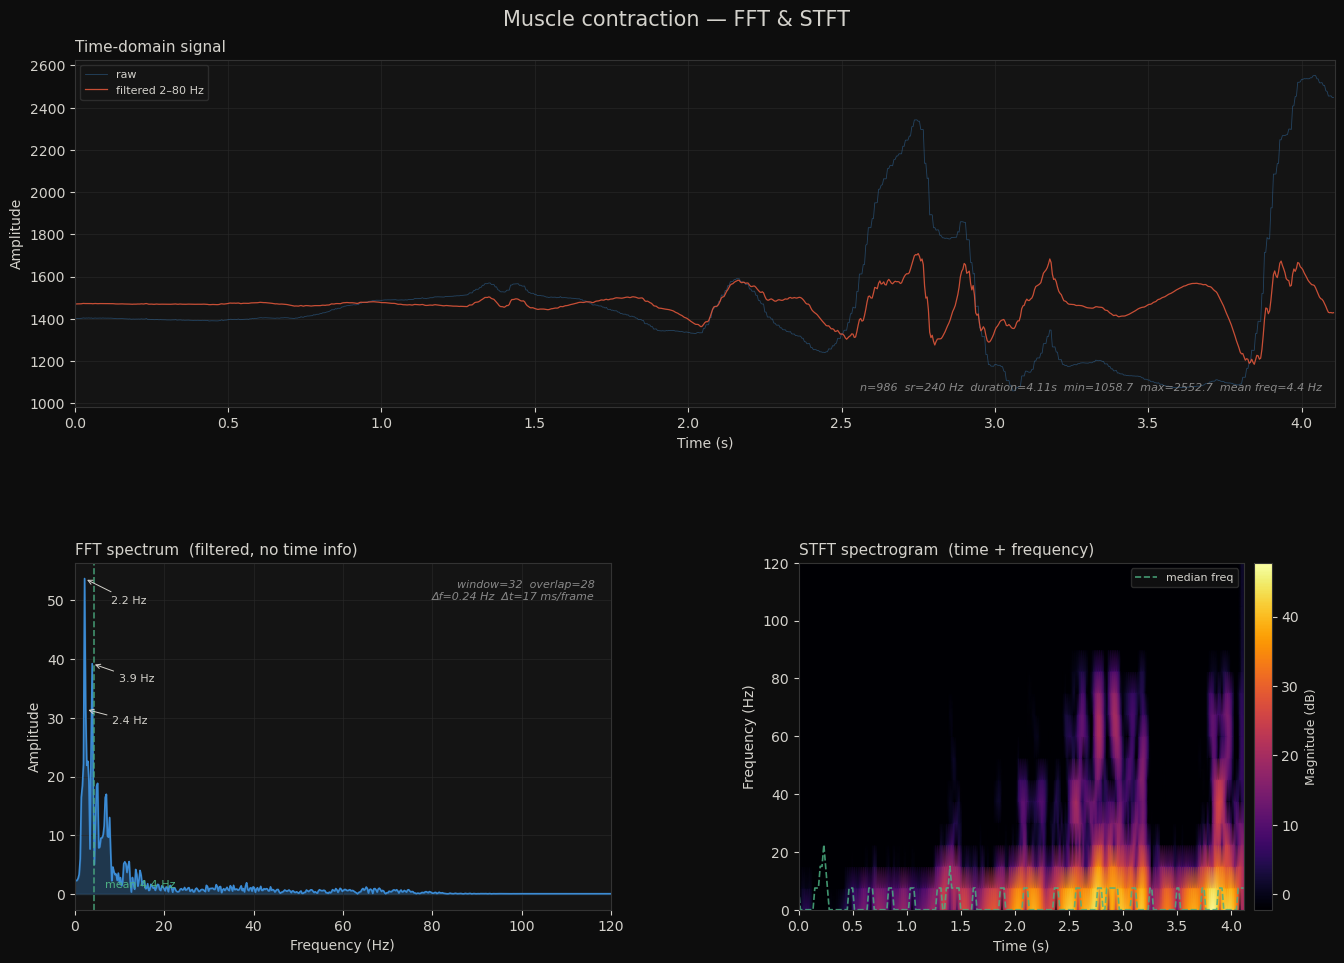

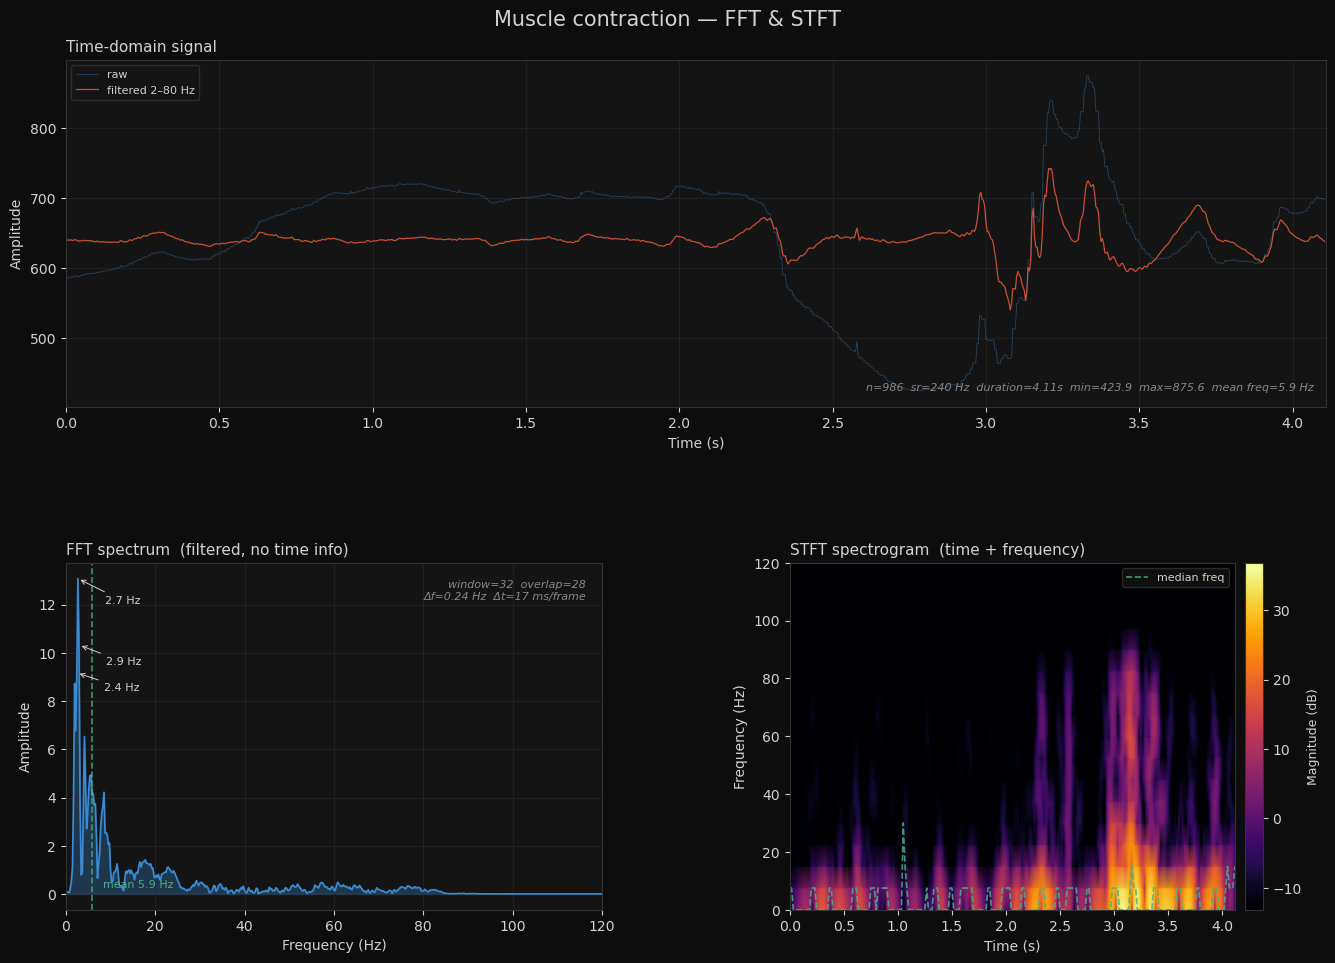

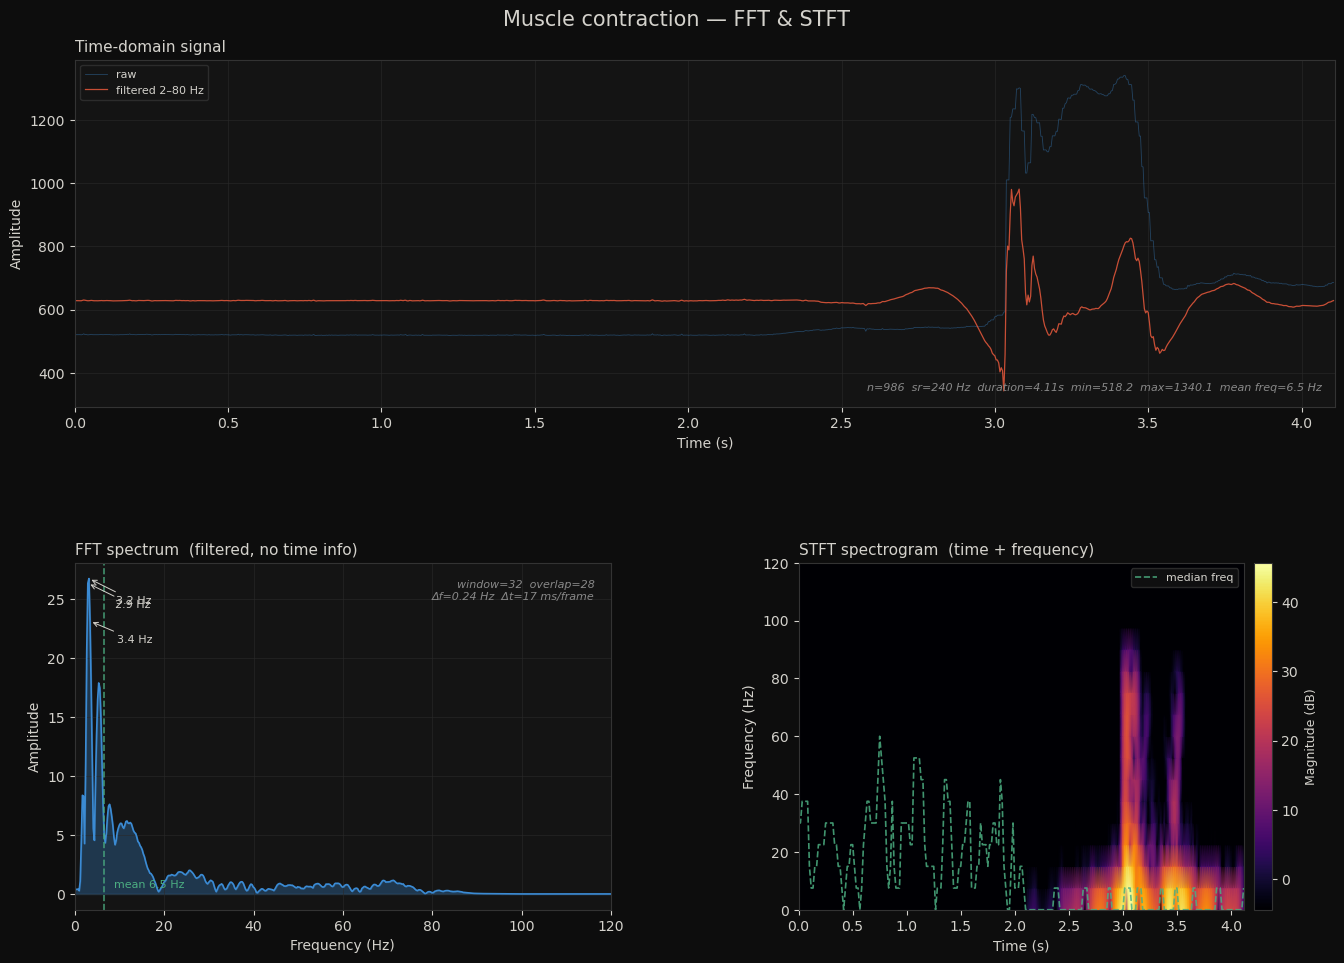

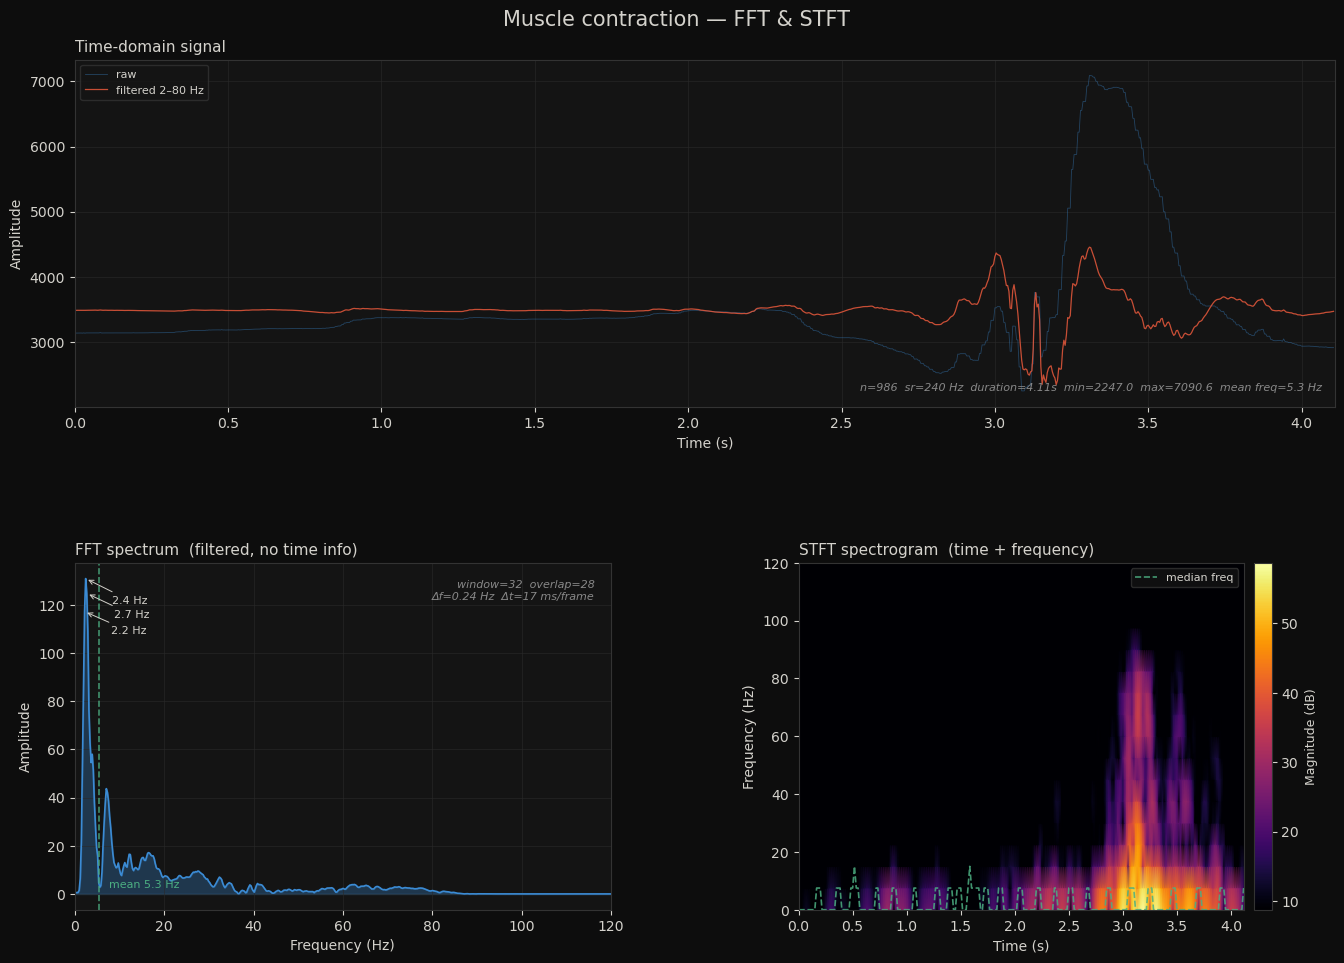

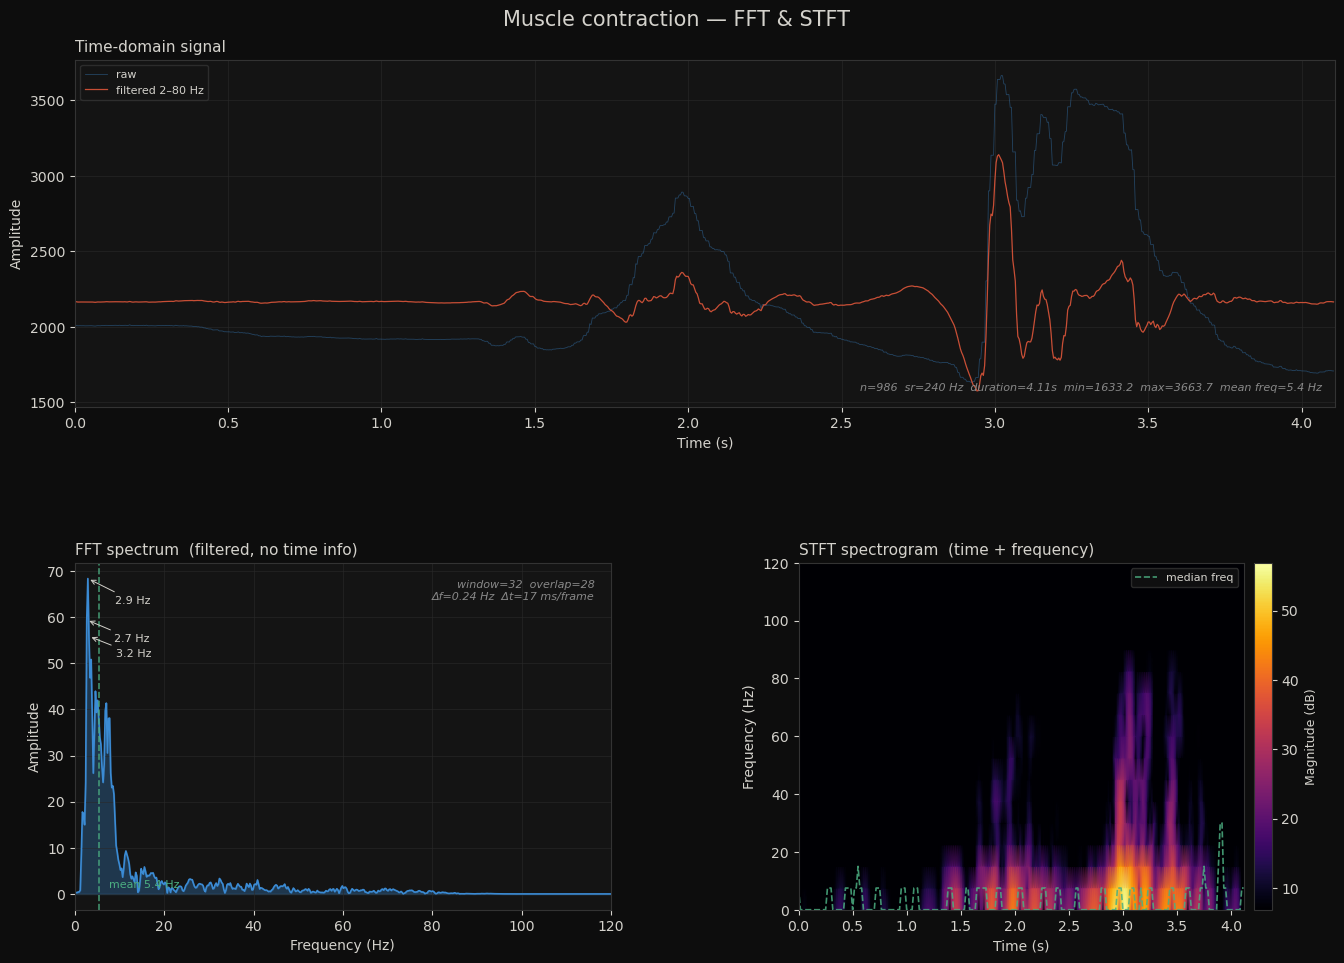

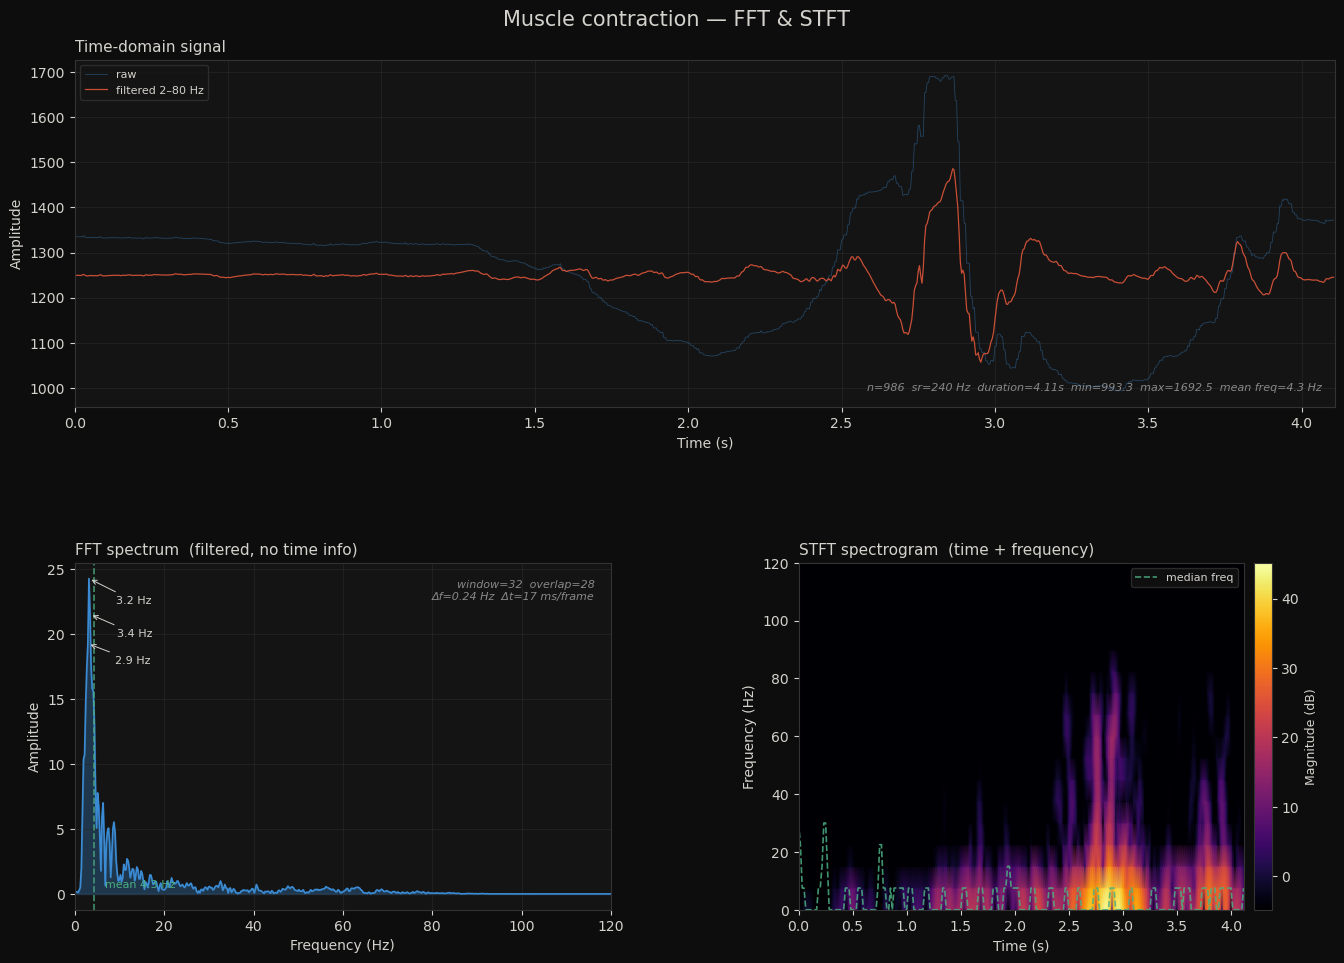

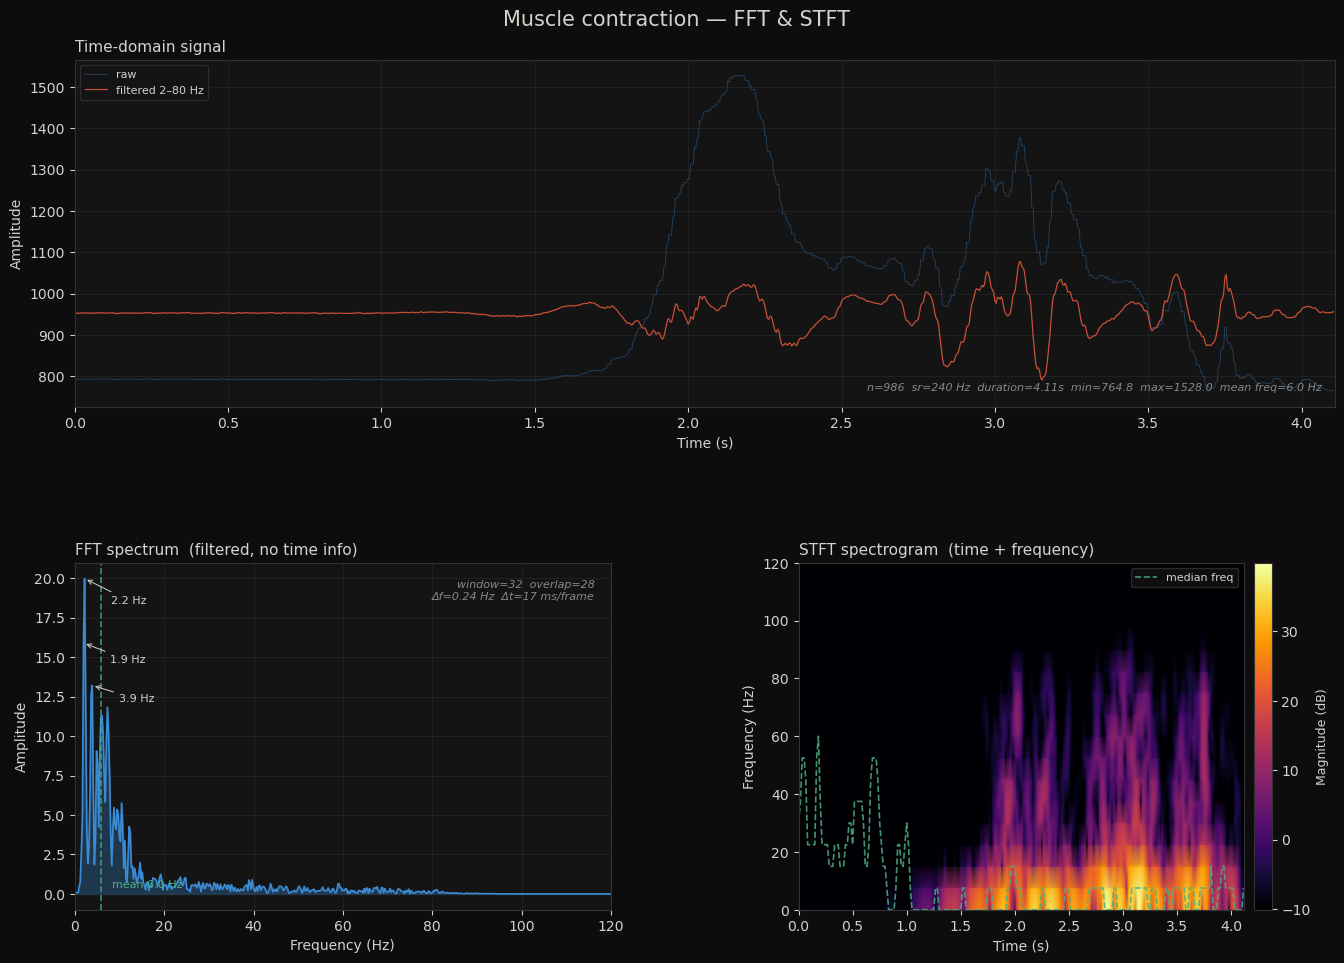

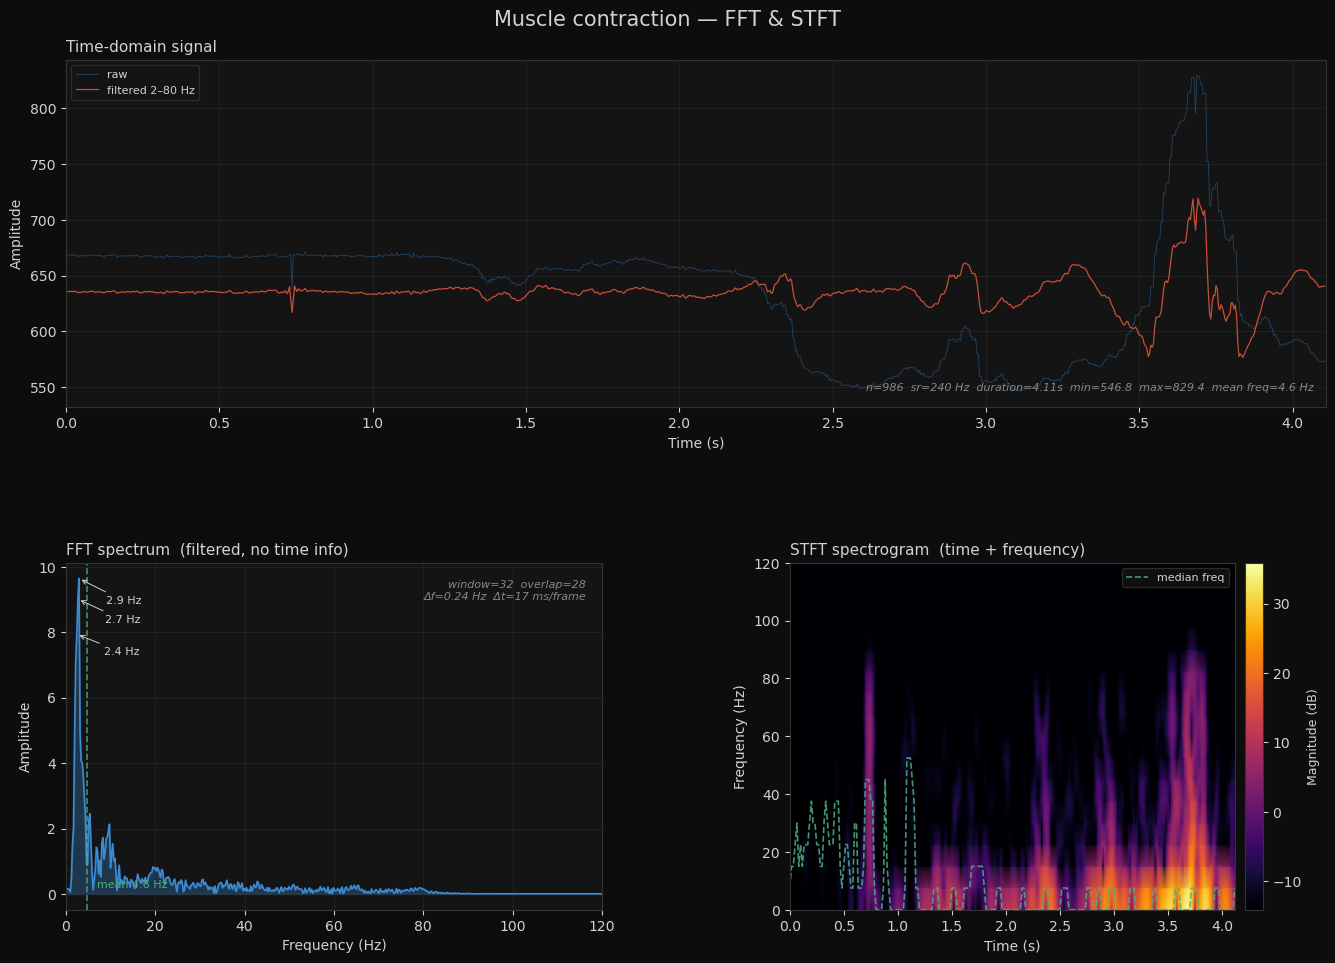

In [39]:
for ts in range(25, 33):
    plot_fft(df[str(ts)], sr=240)